In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("Global_Air_Pollution_Data_2025_2026.csv")

df = df.dropna()

##### Colunas do dataset

In [15]:
print(df.columns)

Index(['Date', 'City', 'Latitude', 'Longitude', 'PM2.5', 'PM10', 'NO2', 'SO2',
       'CO', 'Ozone', 'Aerosol_Optical_Depth', 'AQI_Class'],
      dtype='str')


##### Cidades do dataset

In [16]:
print(df["City"].nunique())

cidades = df["City"].unique()

for cidade in cidades:
    print(cidade)

8
Lahore, Pakistan
Delhi, India
Beijing, China
New York, USA
London, UK
Dhaka, Bangladesh
Sao Paulo, Brazil
Jakarta, Indonesia


##### Quais cidades têm maior poluição de PM2,5?


CIDADES COM MAIOR PM2.5
City
Lahore, Pakistan      127.538919
Delhi, India          118.999038
Beijing, China        116.347665
Dhaka, Bangladesh      75.659020
Jakarta, Indonesia     51.582921
Sao Paulo, Brazil      16.986859
New York, USA          13.232921
London, UK              8.137546
Name: PM2.5, dtype: float64


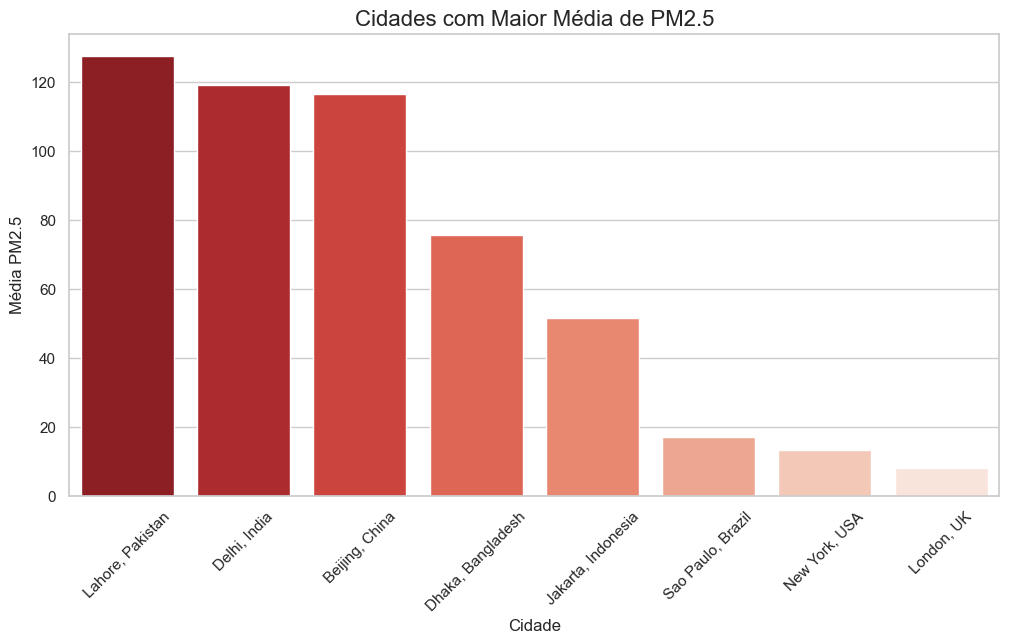

In [17]:
top_pm25 = (
    df.groupby("City")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nCIDADES COM MAIOR PM2.5")
print(top_pm25)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_pm25.reset_index(),
    x="City",
    y="PM2.5",
    hue="City",
    palette="Reds_r",
    legend=False
)

plt.title("Cidades com Maior Média de PM2.5", fontsize=16)
plt.xlabel("Cidade")
plt.ylabel("Média PM2.5")

plt.xticks(rotation=45)

plt.show()

##### Qual poluente possui a maior concentração média?


MEDIA DOS POLUENTES
CO       1264.659741
PM10       69.263124
PM2.5      66.060611
Ozone      54.746337
NO2        38.458871
SO2        30.292691
dtype: float64


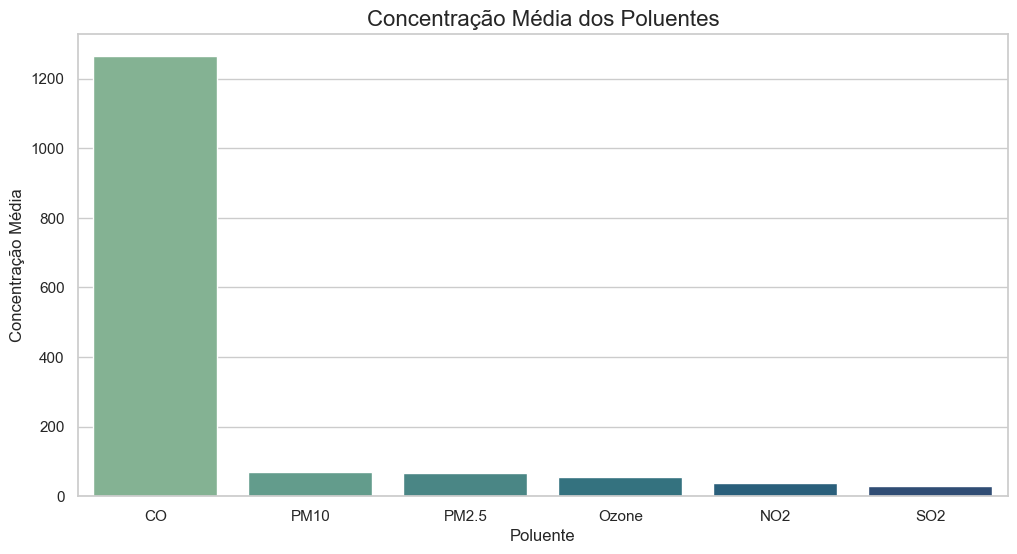

In [18]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "Ozone"
]

pollution_means = (
    df[pollutants]
    .mean()
    .sort_values(ascending=False)
)

print("\nMEDIA DOS POLUENTES")
print(pollution_means)

plt.figure(figsize=(12,6))

sns.barplot(
    x=pollution_means.index,
    y=pollution_means.values,
    hue=pollution_means.index,
    palette="crest",
    legend=False
)

plt.title("Concentração Média dos Poluentes", fontsize=16)
plt.xlabel("Poluente")
plt.ylabel("Concentração Média")

plt.show()

##### Qual a relação entre os níveis de PM2.5 e o risco à saúde?

<ArrowStringArray>
['Unhealthy', 'Unhealthy for Sensitive', 'Moderate', 'Hazardous', 'Good']
Length: 5, dtype: str
AQI_Class
Hazardous                  205.605123
Unhealthy                   94.158191
Unhealthy for Sensitive     45.042182
Moderate                    21.042283
Good                         6.903844
Name: PM2.5, dtype: float64


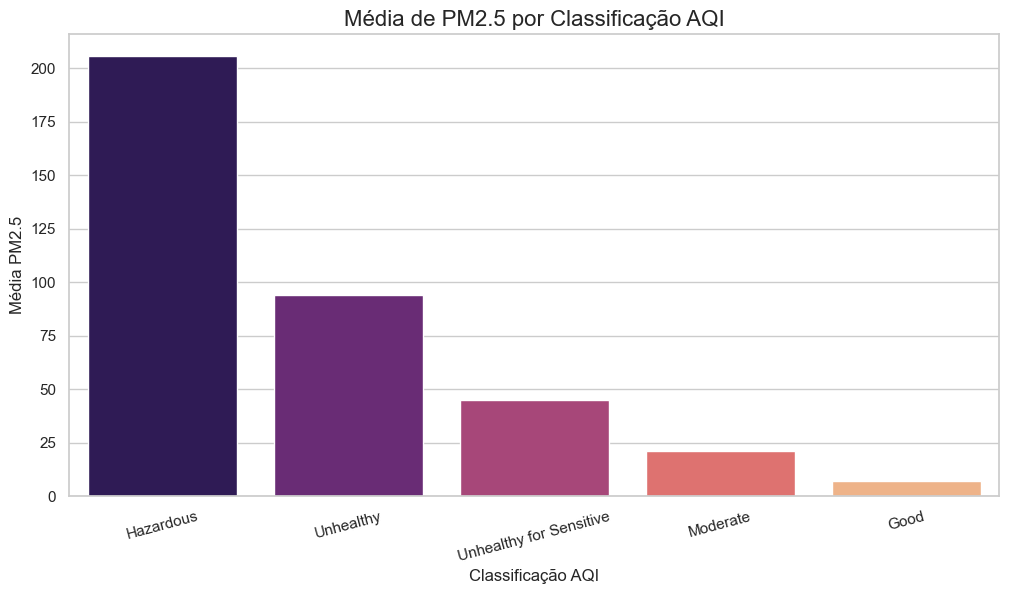

In [19]:
print(df["AQI_Class"].unique())

aqi_analysis = (
    df.groupby("AQI_Class")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

print(aqi_analysis)

plt.figure(figsize=(12,6))

sns.barplot(
    data=aqi_analysis.reset_index(),
    x="AQI_Class",
    y="PM2.5",
    hue="AQI_Class",
    palette="magma",
    legend=False
)

plt.title("Média de PM2.5 por Classificação AQI", fontsize=16)
plt.xlabel("Classificação AQI")
plt.ylabel("Média PM2.5")

plt.xticks(rotation=15)

plt.show()

##### Como os níveis de poluição variam ao longo dos meses do ano?


MEDIA DE PM2.5 POR MES
Month
1     70.234375
2     61.048351
11    59.401630
12    67.797497
Name: PM2.5, dtype: float64


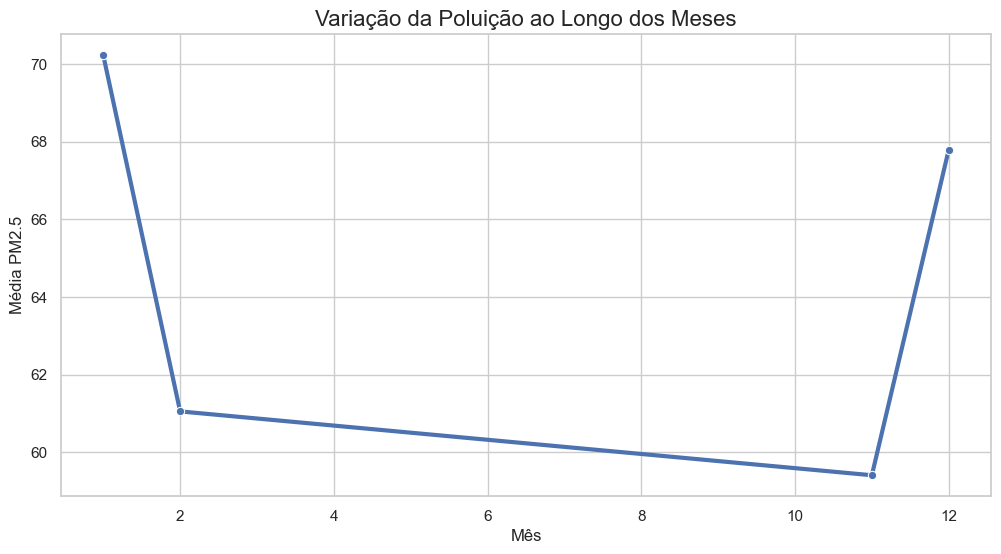

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

monthly_pollution = (
    df.groupby("Month")["PM2.5"]
    .mean()
)

print("\nMEDIA DE PM2.5 POR MES")
print(monthly_pollution)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_pollution.index,
    y=monthly_pollution.values,
    marker="o",
    linewidth=3
)

plt.title("Variação da Poluição ao Longo dos Meses", fontsize=16)
plt.xlabel("Mês")
plt.ylabel("Média PM2.5")

plt.show()

##### Como está evoluindo a poluição do ar (PM2.5) por país entre 2025 e 2026?

      Country  Year       PM2.5
0  Bangladesh  2025   66.995988
1  Bangladesh  2026   88.302365
2      Brazil  2025   18.093056
3      Brazil  2026   15.372410
4       China  2025  118.474228


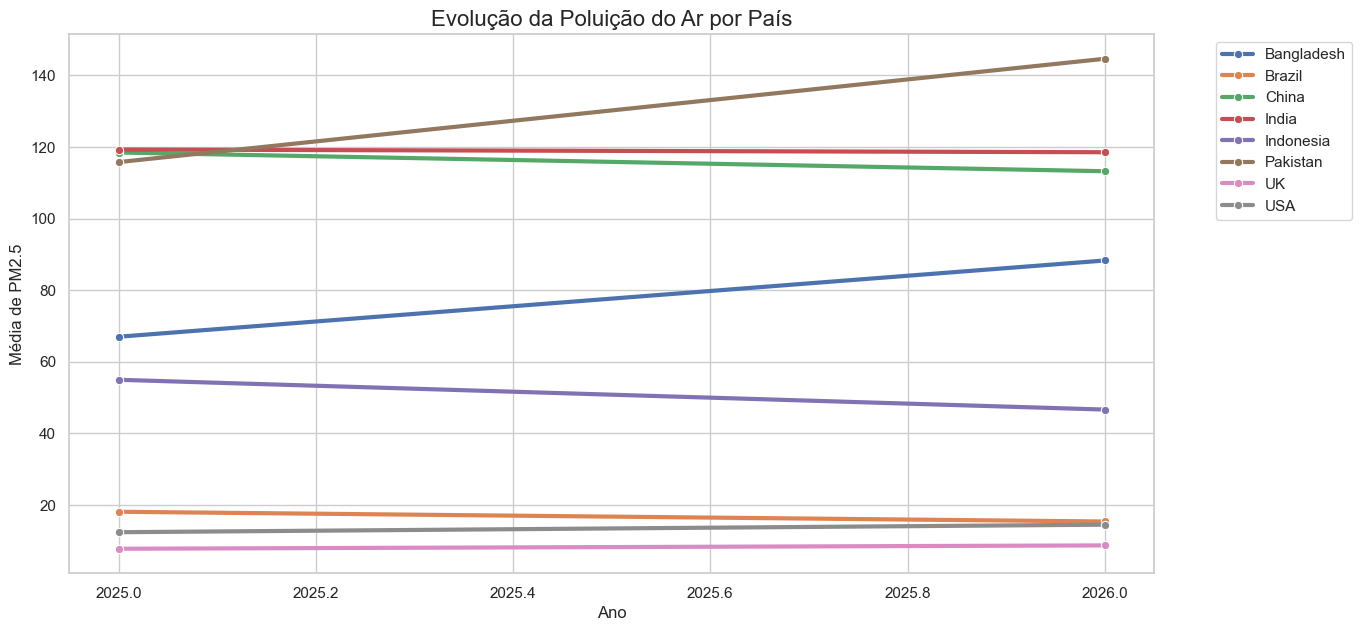


PAISES COM MAIOR PIORA
Year              2025        2026  Diferença
Country                                      
Pakistan    115.799151  144.672635  28.873484
Bangladesh   66.995988   88.302365  21.306377
USA          12.376852   14.482320   2.105468
UK            7.756096    8.694257   0.938161
India       119.307562  118.548761  -0.758800

PAISES COM MAIOR MELHORA
Year             2025        2026  Diferença
Country                                     
UK           7.756096    8.694257   0.938161
India      119.307562  118.548761  -0.758800
Brazil      18.093056   15.372410  -2.720646
China      118.474228  113.244032  -5.230197
Indonesia   54.968904   46.641216  -8.327688


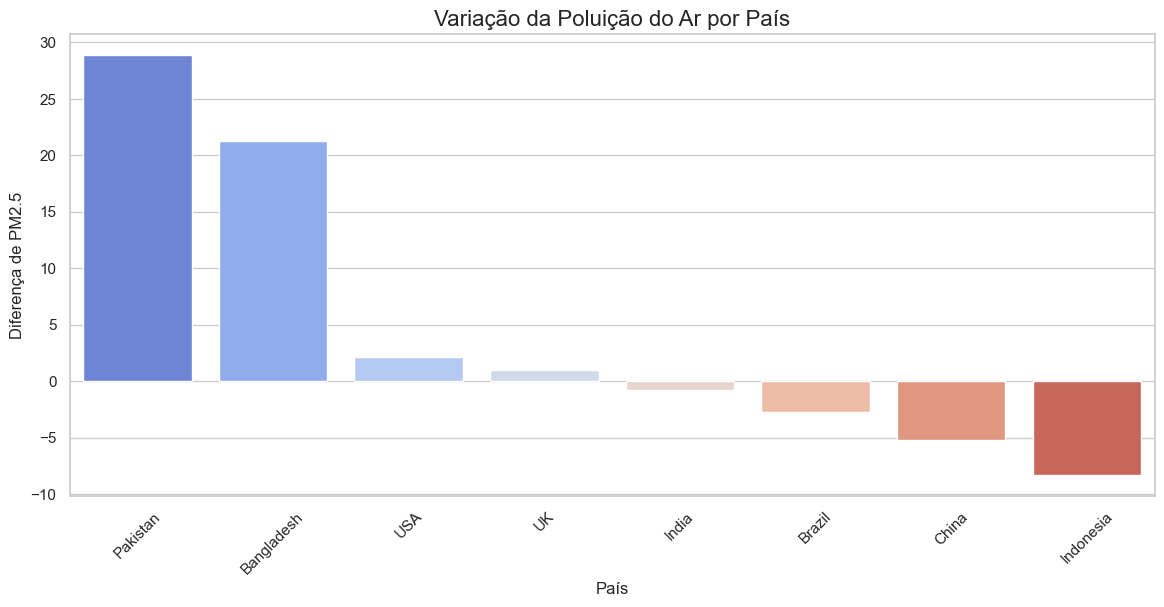

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

# EXTRAIR ANO
df["Year"] = df["Date"].dt.year

df[["City_Name", "Country"]] = df["City"].str.split(",", expand=True)

# REMOVER ESPACOS
df["Country"] = df["Country"].str.strip()

pollution_trend = (
    df.groupby(["Country", "Year"])["PM2.5"]
    .mean()
    .reset_index()
)

print(pollution_trend.head())

plt.figure(figsize=(14,7))

sns.lineplot(
    data=pollution_trend,
    x="Year",
    y="PM2.5",
    hue="Country",
    marker="o",
    linewidth=3
)

plt.title("Evolução da Poluição do Ar por País", fontsize=16)
plt.xlabel("Ano")
plt.ylabel("Média de PM2.5")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

trend_analysis = pollution_trend.pivot(
    index="Country",
    columns="Year",
    values="PM2.5"
)

trend_analysis["Diferença"] = (
    trend_analysis.iloc[:, -1] -
    trend_analysis.iloc[:, 0]
)

trend_analysis = trend_analysis.sort_values(
    by="Diferença",
    ascending=False
)

print("\nPAISES COM MAIOR PIORA")
print(trend_analysis.head())

print("\nPAISES COM MAIOR MELHORA")
print(trend_analysis.tail())

plt.figure(figsize=(14,6))

sns.barplot(
    data=trend_analysis.reset_index(),
    x="Country",
    y="Diferença",
    hue="Country",
    palette="coolwarm",
    legend=False
)

plt.title("Variação da Poluição do Ar por País", fontsize=16)
plt.xlabel("País")
plt.ylabel("Diferença de PM2.5")

plt.xticks(rotation=45)

plt.show()

##### Em quais horários do dia a poluição do ar atinge seus maiores níveis em cada cidade?

Pior horário de PM2.5 por cidade
                   City  Hour       PM2.5
20       Beijing, China    20  173.429670
46         Delhi, India    22  149.892308
55    Dhaka, Bangladesh     7   99.536264
94   Jakarta, Indonesia    22   78.798901
104    Lahore, Pakistan     8  167.521978
141          London, UK    21    9.268132
163       New York, USA    19   18.634066
191   Sao Paulo, Brazil    23   23.250549


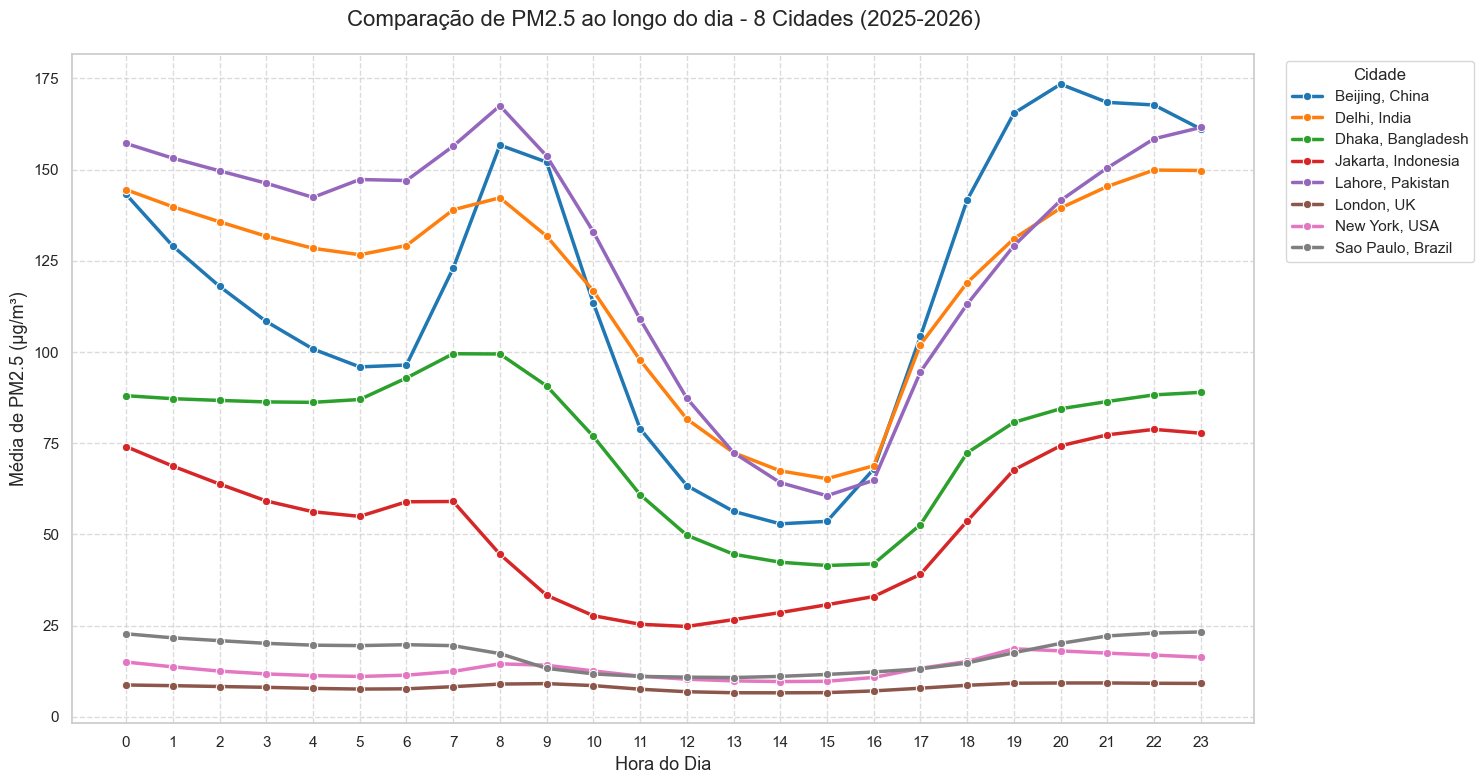

In [22]:
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = df["Date"].dt.hour

cidades = [
    "Lahore, Pakistan", "Delhi, India", "Beijing, China", "New York, USA",
    "London, UK", "Dhaka, Bangladesh", "Sao Paulo, Brazil", "Jakarta, Indonesia"
]

media_hora = df.groupby(["City", "Hour"])["PM2.5"].mean().reset_index()

pior_horario = media_hora.loc[media_hora.groupby("City")["PM2.5"].idxmax()]
print("Pior horário de PM2.5 por cidade")
print(pior_horario[['City', 'Hour', 'PM2.5']])

plt.figure(figsize=(15, 8))

sns.lineplot(data=media_hora, 
             x='Hour', 
             y='PM2.5', 
             hue='City', 
             marker='o', 
             linewidth=2.5,
             palette='tab10')

plt.title('Comparação de PM2.5 ao longo do dia - 8 Cidades (2025-2026)', fontsize=16, pad=20)
plt.xlabel('Hora do Dia', fontsize=13)
plt.ylabel('Média de PM2.5 (µg/m³)', fontsize=13)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cidade', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

##### Existe relação de causa ou dependência entre as variáveis de poluição?

MATRIZ DE CORRELAÇÃO:
                          PM2.5      PM10       NO2       SO2        CO  \
PM2.5                  1.000000  0.992634  0.629595  0.695946  0.748794   
PM10                   0.992634  1.000000  0.622284  0.696194  0.738881   
NO2                    0.629595  0.622284  1.000000  0.459476  0.637073   
SO2                    0.695946  0.696194  0.459476  1.000000  0.651586   
CO                     0.748794  0.738881  0.637073  0.651586  1.000000   
Ozone                 -0.195574 -0.198449 -0.515764 -0.250043 -0.248768   
Aerosol_Optical_Depth  0.596166  0.587748  0.284660  0.302528  0.362096   

                          Ozone  Aerosol_Optical_Depth  
PM2.5                 -0.195574               0.596166  
PM10                  -0.198449               0.587748  
NO2                   -0.515764               0.284660  
SO2                   -0.250043               0.302528  
CO                    -0.248768               0.362096  
Ozone                  1.000000    

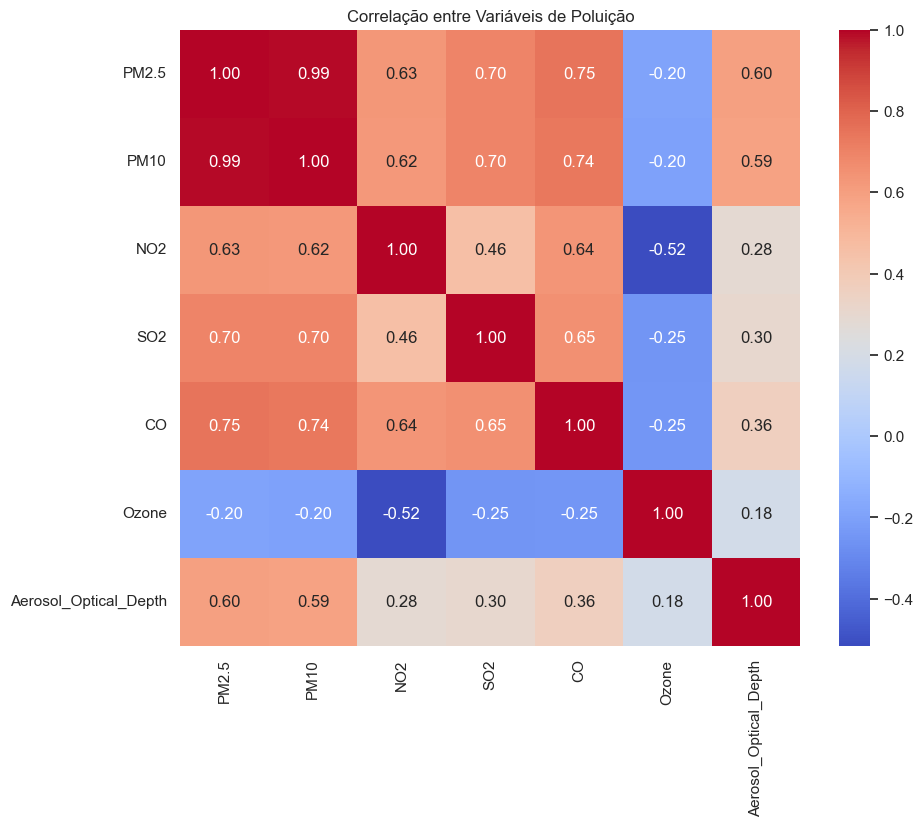

In [23]:
colunas = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "Ozone",
    "Aerosol_Optical_Depth"
]

correlacao = df[colunas].corr()

print("MATRIZ DE CORRELAÇÃO:")
print(correlacao)

plt.figure(figsize=(10,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre Variáveis de Poluição")

plt.show()

##### Qual o potencial impacto econômico da poluição nessas cidades?

 IMPACTO ECONÔMICO POTENCIAL DA POLUIÇÃO - 8 CIDADES 
                    PM25_Medio  PM10_Medio  Horas_Unhealthy  %_Unhealthy  \
City                                                                       
Dhaka, Bangladesh        75.66       77.82             1950         89.3   
Delhi, India            119.00      124.69             1612         73.8   
Lahore, Pakistan        127.54      130.08             1388         63.6   
Jakarta, Indonesia       51.58       52.35             1271         58.2   
Beijing, China          116.35      125.58             1164         53.3   
Sao Paulo, Brazil        16.99       17.49              146          6.7   
New York, USA            13.23       13.67               89          4.1   
London, UK                8.14       12.43                0          0.0   

                    CO_Medio  
City                          
Dhaka, Bangladesh     724.41  
Delhi, India         1401.28  
Lahore, Pakistan     2948.70  
Jakarta, Indonesia   1735.09  

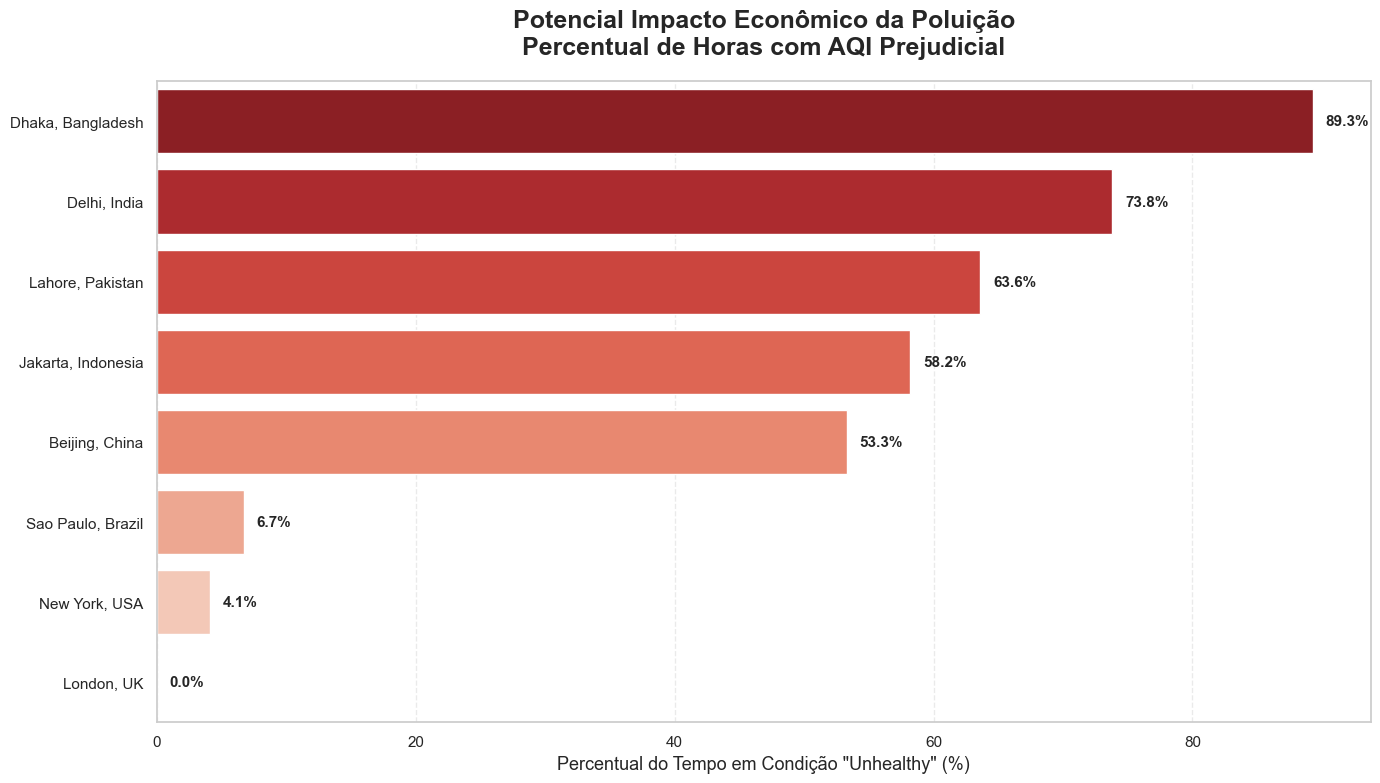

In [24]:
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = df["Date"].dt.hour

cidades = [
    "Lahore, Pakistan",
    "Delhi, India",
    "Beijing, China",
    "New York, USA",
    "London, UK",
    "Dhaka, Bangladesh",
    "Sao Paulo, Brazil",
    "Jakarta, Indonesia"
]

df8 = df[df['City'].isin(cidades)].copy()

impacto = df8.groupby('City').agg(
    PM25_Medio=('PM2.5', 'mean'),
    PM10_Medio=('PM10', 'mean'),
    Horas_Unhealthy=('AQI_Class',
                      lambda x: x.str.contains('Unhealthy', na=False).sum()),
    Total_Horas=('AQI_Class', 'count'),
    CO_Medio=('CO', 'mean')
).round(2)

impacto['%_Unhealthy'] = (
    impacto['Horas_Unhealthy'] /
    impacto['Total_Horas'] * 100
).round(1)

impacto = impacto.sort_values('%_Unhealthy', ascending=False)

print(" IMPACTO ECONÔMICO POTENCIAL DA POLUIÇÃO - 8 CIDADES ")
print(impacto[
    [
        'PM25_Medio',
        'PM10_Medio',
        'Horas_Unhealthy',
        '%_Unhealthy',
        'CO_Medio'
    ]
])

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=impacto.reset_index(),
    y='City',
    x='%_Unhealthy',
    hue='City',
    palette='Reds_r',
    legend=False
)

plt.title(
    'Potencial Impacto Econômico da Poluição\n'
    'Percentual de Horas com AQI Prejudicial',
    fontsize=18,
    pad=20,
    fontweight='bold'
)

plt.xlabel(
    'Percentual do Tempo em Condição "Unhealthy" (%)',
    fontsize=13
)

plt.ylabel('')

for i, valor in enumerate(impacto['%_Unhealthy']):

    ax.text(
        valor + 1,
        i,
        f'{valor}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

##### Como as concentrações dos principais poluentes variam entre as diferentes cidades?

MÉDIA DE POLUENTES POR CIDADE
                     PM2.5       CO    NO2
City                                      
Beijing, China      116.35  2490.47  50.64
Delhi, India        119.00  1401.28  44.54
Dhaka, Bangladesh    75.66   724.41  23.33
Jakarta, Indonesia   51.58  1735.09  46.76
Lahore, Pakistan    127.54  2948.70  60.86
London, UK            8.14   191.97  28.50
New York, USA        13.23   317.49  33.96
Sao Paulo, Brazil    16.99   307.87  19.07


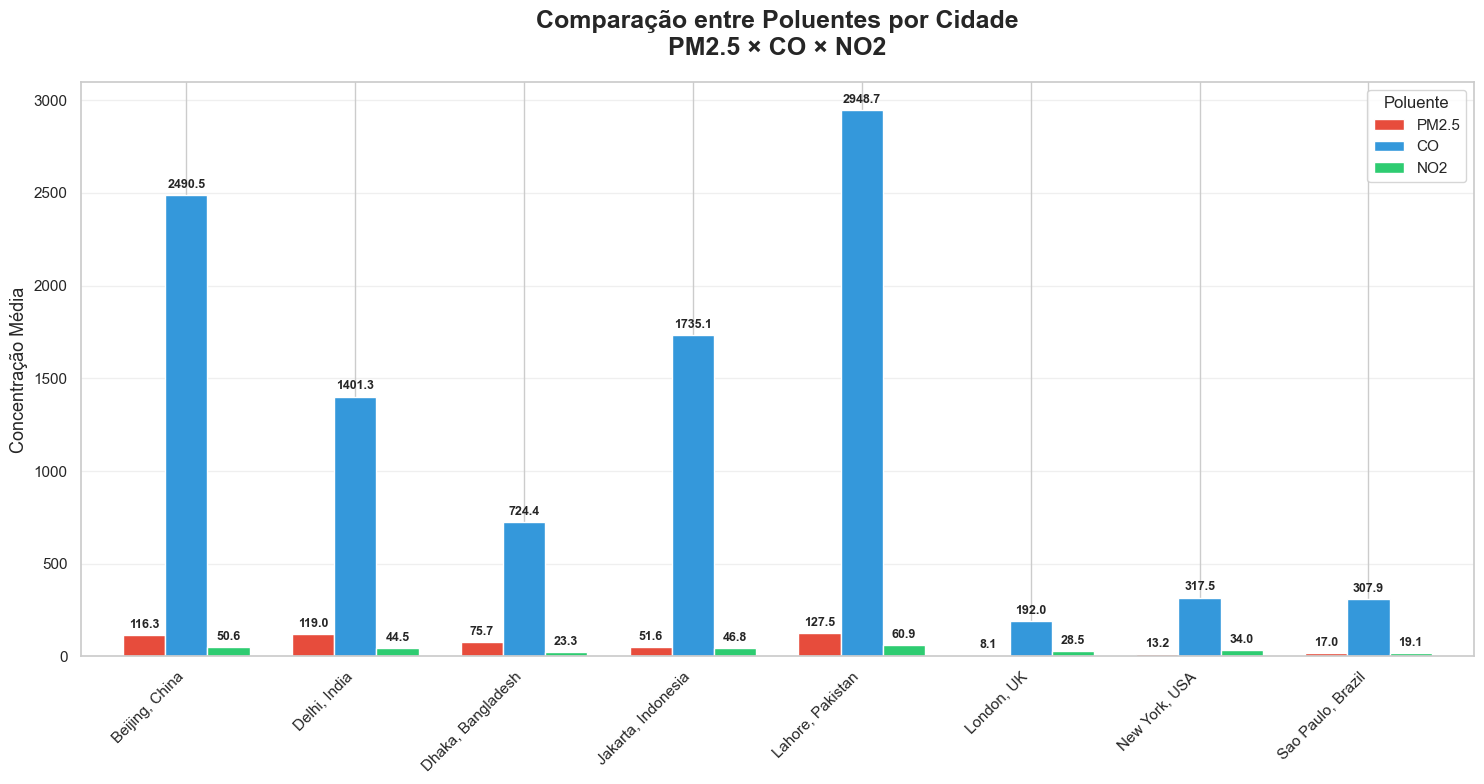

In [25]:
media_poluentes = df[df['City'].isin(cidades)].groupby('City')[['PM2.5', 'CO', 'NO2']].mean().round(2)

print("MÉDIA DE POLUENTES POR CIDADE")
print(media_poluentes)

ax = media_poluentes.plot(
    kind='bar', 
    figsize=(15, 8), 
    width=0.75,
    color=['#e74c3c', '#3498db', '#2ecc71']
)

plt.title('Comparação entre Poluentes por Cidade\nPM2.5 × CO × NO2', 
          fontsize=18, fontweight='bold', pad=20)

plt.ylabel('Concentração Média', fontsize=13)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(title='Poluente', title_fontsize=12, fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

##### Qual é o grau de instabilidade e variação na qualidade do ar entre as cidades?

INSTABILIDADE DA QUALIDADE DO AR
                    PM25_Medio  Desvio_PM25
City                                       
Beijing, China          116.35        81.85
Lahore, Pakistan        127.54        62.28
Delhi, India            119.00        57.19
Jakarta, Indonesia       51.58        33.21
Dhaka, Bangladesh        75.66        32.83
New York, USA            13.23        10.46
Sao Paulo, Brazil        16.99        10.37
London, UK                8.14         4.77


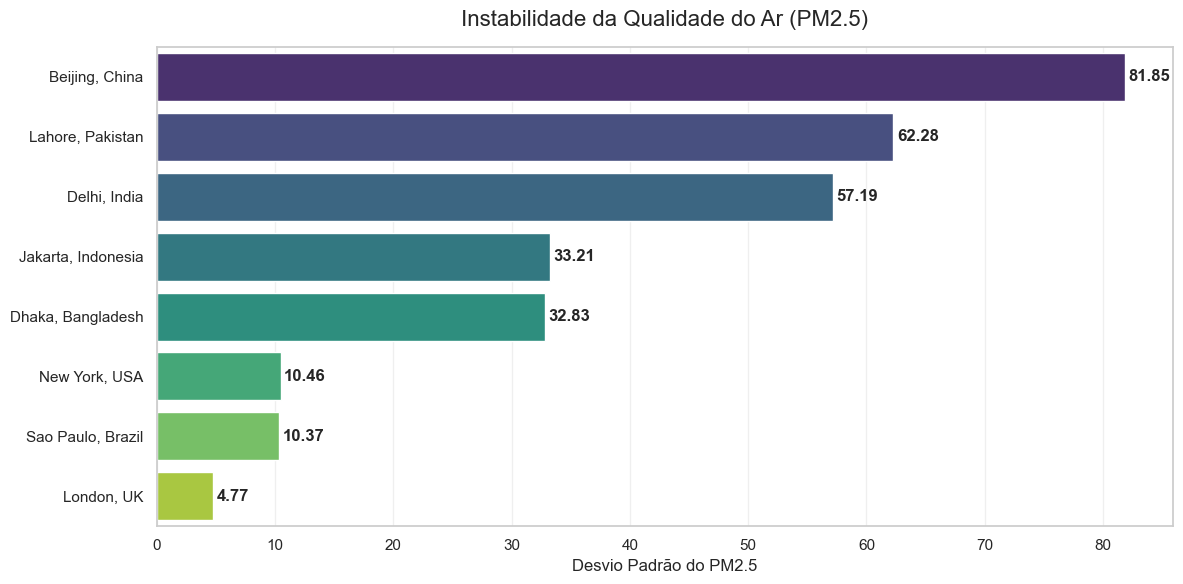

In [26]:
instabilidade = df.groupby("City").agg(

    PM25_Medio=("PM2.5", "mean"),

    Desvio_PM25=("PM2.5", "std")

).round(2)

instabilidade = instabilidade.sort_values(
    "Desvio_PM25",
    ascending=False
)

print("INSTABILIDADE DA QUALIDADE DO AR")
print(instabilidade)

plt.figure(figsize=(12,6))

sns.barplot(
    data=instabilidade.reset_index(),
    y="City",
    x="Desvio_PM25",
    hue="City",
    palette="viridis",
    legend=False
)

plt.title(
    "Instabilidade da Qualidade do Ar (PM2.5)",
    fontsize=16,
    pad=15
)

plt.xlabel("Desvio Padrão do PM2.5")

plt.ylabel("")

for i, valor in enumerate(instabilidade["Desvio_PM25"]):

    plt.text(
        valor + 0.3,
        i,
        f"{valor}",
        va='center',
        fontweight='bold'
    )

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()